# Assignment: Neural Network (NN)

## Dataset Loading and Initial Exploration

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the raw dataset URL
DATASET_URL = 'https://github.com/ToufiqImrose/AI-ML/blob/main/AI_ML/ANN/Dataset/heart.csv?raw=true'

df = pd.read_csv(DATASET_URL)


In [73]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [74]:
# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [75]:
# Display descriptive statistics of the DataFrame
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Preprocessing

### 1. Handling Missing Data

In [76]:
# Check for missing values
print("Number of missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found. Further action required.")

Number of missing values per column:
Series([], dtype: int64)
No missing values found in the dataset.


### 2. Identifying Categorical and Numerical Features

In [77]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


all_features = categorical_cols + numerical_cols
if set(df.drop('target', axis=1).columns) != set(all_features):
    print("Warning: Some columns might not be correctly categorized or are missing.")
    print("Uncategorized columns:", set(df.drop('target', axis=1).columns) - set(all_features))

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


### 3. Outlier Detection for Numerical Columns (using Boxplots)

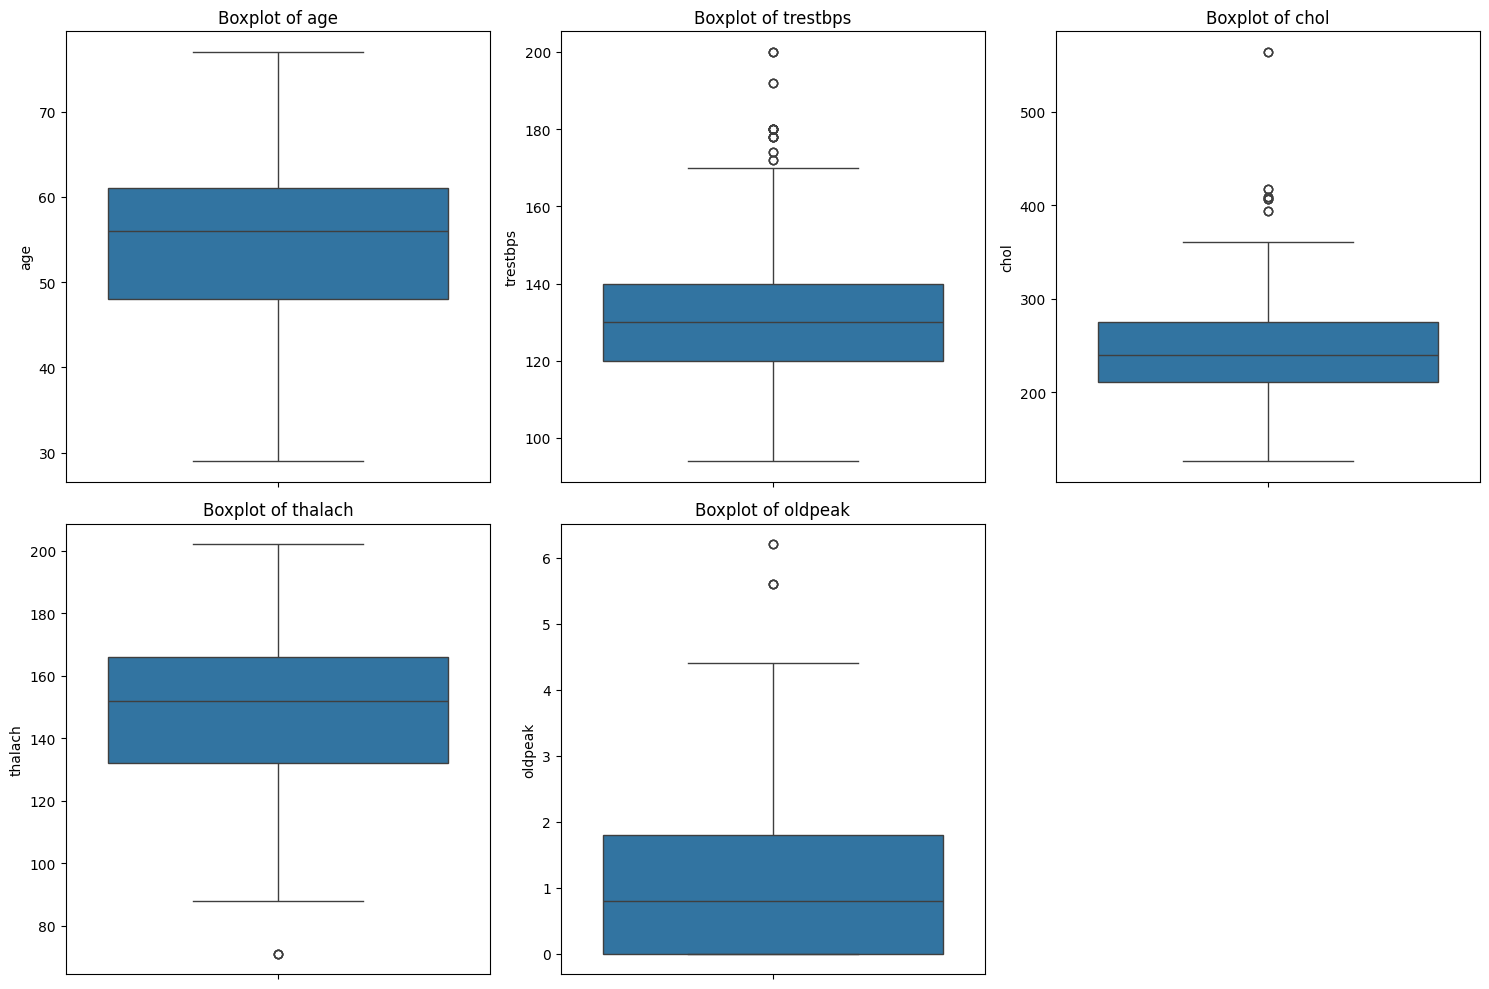

In [78]:
# Visualize outliers using boxplots for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

These boxplots show the distribution and outliers of important numerical features in the Heart Disease dataset. The age feature has a fairly balanced spread with no major outliers, indicating a stable distribution. Variables like trestbps, chol, and oldpeak contain several outliers, which may represent extreme patient conditions or unusual measurements. The thalach feature is mostly centered but has a few lower outliers. Overall, the visualization helps identify data variability and potential outliers that may affect model performance.

### 4. Encoding Categorical Features

In [79]:
# Apply One-Hot Encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())
print(f"Shape of DataFrame after encoding: {df_encoded.shape}")

DataFrame after One-Hot Encoding:


,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,52,125,212,168,1.0,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,70,145,174,125,2.6,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,61,148,203,161,0.0,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


Shape of DataFrame after encoding: (1025, 23)


### 5. Feature Scaling (for Numerical Features)

In [80]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_encoded.copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

print("DataFrame after scaling numerical features:")
display(df_scaled.head())
print(f"Shape of DataFrame after scaling: {df_scaled.shape}")

DataFrame after scaling numerical features:


,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0,True,False,False,False,...,False,False,True,False,True,False,False,False,False,True
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0,True,False,False,False,...,False,False,True,True,False,False,False,False,False,True
4,0.834359,0.364875,0.930822,-1.874977,0.705408,0,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False


Shape of DataFrame after scaling: (1025, 23)


### 6. Split the Data into Stratified Train and Test Sets

In [81]:
from sklearn.model_selection import train_test_split

X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTarget distribution in original dataset:")
print(y.value_counts(normalize=True))
print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in test set:")
print(y_test.value_counts(normalize=True))

X_train shape: (820, 22)
X_test shape: (205, 22)
y_train shape: (820,)
y_test shape: (205,)

Target distribution in original dataset:
target
1    0.513171
0    0.486829
Name: proportion, dtype: float64

Target distribution in training set:
target
1    0.513415
0    0.486585
Name: proportion, dtype: float64

Target distribution in test set:
target
1    0.512195
0    0.487805
Name: proportion, dtype: float64


## Shallow NN Implementation

### 1. Prepare Data for PyTorch

In [82]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train.values.astype(np.float32), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values.astype(np.float32), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print(f"X_train_tensor shape: {X_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"X_test_tensor shape: {X_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Determine input size
input_size = X_train_tensor.shape[1]
print(f"Input size for the neural network: {input_size}")

X_train_tensor shape: torch.Size([820, 22])
y_train_tensor shape: torch.Size([820, 1])
X_test_tensor shape: torch.Size([205, 22])
y_test_tensor shape: torch.Size([205, 1])
Input size for the neural network: 22


### 2. Shallow Neural Network Architecture

In [83]:
class ShallowNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, activation_fn=nn.ReLU):
        super(ShallowNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.activation = activation_fn()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid() # For binary classification output

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

print("ShallowNN class defined.")

ShallowNN class defined.


### 3. Hyperparameter Tuning for Shallow NN

To perform hyperparameter tuning, we first need to create a validation set from the training data. This will allow us to evaluate different hyperparameter combinations without touching the final test set.

In [84]:
from sklearn.model_selection import train_test_split

X_train_df, X_val_df, y_train_s, y_val_s = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

# Convert the split pandas DataFrames/Series to PyTorch tensors
X_train_tuned_tensor = torch.tensor(X_train_df.values.astype(np.float32), dtype=torch.float32)
y_train_tuned_tensor = torch.tensor(y_train_s.values, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val_df.values.astype(np.float32), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_s.values, dtype=torch.float32).unsqueeze(1)

# Create TensorDatasets for tuning
train_tuning_dataset = TensorDataset(X_train_tuned_tensor, y_train_tuned_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

print(f"X_train_tuned_tensor shape: {X_train_tuned_tensor.shape}")
print(f"y_train_tuned_tensor shape: {y_train_tuned_tensor.shape}")
print(f"X_val_tensor shape: {X_val_tensor.shape}")
print(f"y_val_tensor shape: {y_val_tensor.shape}")

X_train_tuned_tensor shape: torch.Size([615, 22])
y_train_tuned_tensor shape: torch.Size([615, 1])
X_val_tensor shape: torch.Size([205, 22])
y_val_tensor shape: torch.Size([205, 1])


In [85]:
import itertools
from sklearn.metrics import accuracy_score

def train_and_evaluate_shallow_nn(model, train_loader, val_loader, epochs, learning_rate):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Store history for plotting
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            predicted = (outputs > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = correct_train / total_train
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                outputs_val = model(inputs_val)
                loss_val = criterion(outputs_val, labels_val)
                val_loss += loss_val.item()

                predicted_val = (outputs_val > 0.5).float()
                total_val += labels_val.size(0)
                correct_val += (predicted_val == labels_val).sum().item()

        val_loss = val_loss / len(val_loader)
        val_accuracy = correct_val / total_val
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)



    return val_accuracy, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

# Define hyperparameter grid for Shallow NN
hidden_units_options = [32, 64, 128]
activation_functions = [nn.ReLU, nn.Sigmoid, nn.Tanh]
batch_sizes = [16, 32, 64]
learning_rates = [0.001, 0.005]
epochs_for_tuning = 50

best_val_accuracy = -1
best_hyperparameters = {}
best_model = None
best_history = None

# Iterate over all combinations of hyperparameters
for hidden_size, activation_fn, batch_size, lr in itertools.product(
    hidden_units_options, activation_functions, batch_sizes, learning_rates
):
    print(f"\n--- Tuning with hidden_size={hidden_size}, activation_fn={activation_fn.__name__}, batch_size={batch_size}, lr={lr} ---")

    # Create DataLoaders for this batch size
    train_loader_tuned = DataLoader(train_tuning_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = ShallowNN(input_size, hidden_size, output_size=1, activation_fn=activation_fn)

    # Train and evaluate
    current_val_accuracy, history = train_and_evaluate_shallow_nn(model, train_loader_tuned, val_loader, epochs_for_tuning, lr)

    print(f"Validation Accuracy: {current_val_accuracy:.4f}")

    # Check if this is the best model so far
    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        best_hyperparameters = {
            'hidden_size': hidden_size,
            'activation_fn': activation_fn,
            'batch_size': batch_size,
            'learning_rate': lr
        }
        best_model = model
        best_history = history

print(f"\nBest Shallow NN Hyperparameters: {best_hyperparameters}")
print(f"Best Shallow NN Validation Accuracy: {best_val_accuracy:.4f}")


--- Tuning with hidden_size=32, activation_fn=ReLU, batch_size=16, lr=0.001 ---
Validation Accuracy: 0.9024

--- Tuning with hidden_size=32, activation_fn=ReLU, batch_size=16, lr=0.005 ---
Validation Accuracy: 0.9756

--- Tuning with hidden_size=32, activation_fn=ReLU, batch_size=32, lr=0.001 ---
Validation Accuracy: 0.8927

--- Tuning with hidden_size=32, activation_fn=ReLU, batch_size=32, lr=0.005 ---
Validation Accuracy: 0.9463

--- Tuning with hidden_size=32, activation_fn=ReLU, batch_size=64, lr=0.001 ---
Validation Accuracy: 0.8732

--- Tuning with hidden_size=32, activation_fn=ReLU, batch_size=64, lr=0.005 ---
Validation Accuracy: 0.9463

--- Tuning with hidden_size=32, activation_fn=Sigmoid, batch_size=16, lr=0.001 ---
Validation Accuracy: 0.8634

--- Tuning with hidden_size=32, activation_fn=Sigmoid, batch_size=16, lr=0.005 ---
Validation Accuracy: 0.8927

--- Tuning with hidden_size=32, activation_fn=Sigmoid, batch_size=32, lr=0.001 ---
Validation Accuracy: 0.8585

--- Tunin

### 4. Train Best Shallow NN on Full Training Data and Evaluate

In [86]:
def train_model(model, train_loader, val_loader, epochs, learning_rate):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            predicted = (outputs > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct_train / total_train)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                outputs_val = model(inputs_val)
                loss_val = criterion(outputs_val, labels_val)
                val_loss += loss_val.item()
                predicted_val = (outputs_val > 0.5).float()
                total_val += labels_val.size(0)
                correct_val += (predicted_val == labels_val).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct_val / total_val)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }


# Retrieve best hyperparameters
hidden_size_shallow = best_hyperparameters['hidden_size']
activation_fn_shallow = best_hyperparameters['activation_fn']
batch_size_shallow = best_hyperparameters['batch_size']
learning_rate_shallow = best_hyperparameters['learning_rate']
epochs_shallow = 200 # More epochs for final training

# Initialize the best Shallow NN model
best_shallow_nn = ShallowNN(input_size, hidden_size_shallow, output_size=1, activation_fn=activation_fn_shallow)

# Create DataLoaders for the full training and original test set
train_loader_shallow = DataLoader(train_dataset, batch_size=batch_size_shallow, shuffle=True)
test_loader_shallow = DataLoader(test_dataset, batch_size=batch_size_shallow, shuffle=False)

print("Training Shallow NN with best hyperparameters...")
shallow_nn_history = train_model(best_shallow_nn, train_loader_shallow, test_loader_shallow, epochs_shallow, learning_rate_shallow)
print("Shallow NN Training complete.")

# Evaluate on the test set
best_shallow_nn.eval()
y_pred_shallow = []
y_true_shallow = []
with torch.no_grad():
    for inputs, labels in test_loader_shallow:
        outputs = best_shallow_nn(inputs)
        predicted = (outputs > 0.5).float()
        y_pred_shallow.extend(predicted.cpu().numpy())
        y_true_shallow.extend(labels.cpu().numpy())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_shallow = accuracy_score(y_true_shallow, y_pred_shallow)
precision_shallow = precision_score(y_true_shallow, y_pred_shallow)
recall_shallow = recall_score(y_true_shallow, y_pred_shallow)
f1_shallow = f1_score(y_true_shallow, y_pred_shallow)
auc_shallow = roc_auc_score(y_true_shallow, y_pred_shallow)

print(f"\nShallow NN Test Accuracy: {accuracy_shallow:.4f}")
print(f"Shallow NN Test Precision: {precision_shallow:.4f}")
print(f"Shallow NN Test Recall: {recall_shallow:.4f}")
print(f"Shallow NN Test F1-Score: {f1_shallow:.4f}")
print(f"Shallow NN Test AUC: {auc_shallow:.4f}")

Training Shallow NN with best hyperparameters...
Shallow NN Training complete.

Shallow NN Test Accuracy: 1.0000
Shallow NN Test Precision: 1.0000
Shallow NN Test Recall: 1.0000
Shallow NN Test F1-Score: 1.0000
Shallow NN Test AUC: 1.0000


## Deep NN Implementation

### 1. Deep Neural Network Architecture

In [87]:
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_layers, output_size, activation_fn=nn.ReLU, dropout_rate=0.5):
        super(DeepNN, self).__init__()
        layers = []
        prev_size = input_size
        for i, h_size in enumerate(hidden_layers):
            layers.append(nn.Linear(prev_size, h_size))
            layers.append(activation_fn())
            layers.append(nn.Dropout(dropout_rate)) # Dropout for regularization
            prev_size = h_size

        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.network(x)
        x = self.sigmoid(x)
        return x

print("DeepNN class defined with Dropout regularization.")

DeepNN class defined with Dropout regularization.


### 2. Hyperparameter Tuning for Deep NN

In [88]:
from sklearn.model_selection import train_test_split

X_train_deep_df, X_val_deep_df, y_train_deep_s, y_val_deep_s = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

# Convert the split pandas DataFrames/Series to PyTorch tensors
X_train_deep_tuned_tensor = torch.tensor(X_train_deep_df.values.astype(np.float32), dtype=torch.float32)
y_train_deep_tuned_tensor = torch.tensor(y_train_deep_s.values, dtype=torch.float32).unsqueeze(1)
X_val_deep_tensor = torch.tensor(X_val_deep_df.values.astype(np.float32), dtype=torch.float32)
y_val_deep_tensor = torch.tensor(y_val_deep_s.values, dtype=torch.float32).unsqueeze(1)


# Create TensorDatasets for tuning
train_tuning_dataset_deep = TensorDataset(X_train_deep_tuned_tensor, y_train_deep_tuned_tensor)
val_dataset_deep = TensorDataset(X_val_deep_tensor, y_val_deep_tensor)

print(f"X_train_deep_tuned_tensor shape: {X_train_deep_tuned_tensor.shape}")
print(f"y_train_deep_tuned_tensor shape: {y_train_deep_tuned_tensor.shape}")
print(f"X_val_deep_tensor shape: {X_val_deep_tensor.shape}")
print(f"y_val_deep_tensor shape: {y_val_deep_tensor.shape}")

X_train_deep_tuned_tensor shape: torch.Size([615, 22])
y_train_deep_tuned_tensor shape: torch.Size([615, 1])
X_val_deep_tensor shape: torch.Size([205, 22])
y_val_deep_tensor shape: torch.Size([205, 1])


In [89]:
import itertools

def train_and_evaluate_deep_nn(model, train_loader, val_loader, epochs, learning_rate, optimizer_class):
    criterion = nn.BCELoss()
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Validation phase - only interested in final accuracy for tuning
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                outputs_val = model(inputs_val)
                predicted_val = (outputs_val > 0.5).float()
                total_val += labels_val.size(0)
                correct_val += (predicted_val == labels_val).sum().item()

    val_accuracy = correct_val / total_val
    return val_accuracy

# Define hyperparameter grid for Deep NN
hidden_layers_options = [[64, 32, 16], [128, 64, 32], [128, 64, 32, 16]]
learning_rates_deep = [0.001, 0.0005]
optimizers = [optim.Adam, optim.SGD]
batch_sizes_deep = [32, 64]
dropout_rates = [0.2, 0.4]
epochs_for_tuning_deep = 50

best_val_accuracy_deep = -1
best_hyperparameters_deep = {}

# Iterate over all combinations of hyperparameters
for hidden_layers, lr, optimizer_class, batch_size, dropout_rate in itertools.product(
    hidden_layers_options, learning_rates_deep, optimizers, batch_sizes_deep, dropout_rates
):
    print(f"\n--- Tuning Deep NN: hidden_layers={hidden_layers}, lr={lr}, optimizer={optimizer_class.__name__}, batch_size={batch_size}, dropout={dropout_rate} ---")

    # Create DataLoaders for this batch size
    train_loader_deep_tuned = DataLoader(train_tuning_dataset_deep, batch_size=batch_size, shuffle=True)
    val_loader_deep = DataLoader(val_dataset_deep, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = DeepNN(input_size, hidden_layers, output_size=1, activation_fn=nn.ReLU, dropout_rate=dropout_rate)

    # Train and evaluate
    current_val_accuracy = train_and_evaluate_deep_nn(model, train_loader_deep_tuned, val_loader_deep, epochs_for_tuning_deep, lr, optimizer_class)

    print(f"Validation Accuracy: {current_val_accuracy:.4f}")

    # Check if this is the best model so far
    if current_val_accuracy > best_val_accuracy_deep:
        best_val_accuracy_deep = current_val_accuracy
        best_hyperparameters_deep = {
            'hidden_layers': hidden_layers,
            'learning_rate': lr,
            'optimizer': optimizer_class,
            'batch_size': batch_size,
            'dropout_rate': dropout_rate
        }

print(f"\nBest Deep NN Hyperparameters: {best_hyperparameters_deep}")
print(f"Best Deep NN Validation Accuracy: {best_val_accuracy_deep:.4f}")


--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimizer=Adam, batch_size=32, dropout=0.2 ---
Validation Accuracy: 0.9512

--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimizer=Adam, batch_size=32, dropout=0.4 ---
Validation Accuracy: 0.9415

--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimizer=Adam, batch_size=64, dropout=0.2 ---
Validation Accuracy: 0.9268

--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimizer=Adam, batch_size=64, dropout=0.4 ---
Validation Accuracy: 0.9122

--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimizer=SGD, batch_size=32, dropout=0.2 ---
Validation Accuracy: 0.4878

--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimizer=SGD, batch_size=32, dropout=0.4 ---
Validation Accuracy: 0.5122

--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimizer=SGD, batch_size=64, dropout=0.2 ---
Validation Accuracy: 0.4878

--- Tuning Deep NN: hidden_layers=[64, 32, 16], lr=0.001, optimi

### 3. Train Best Deep NN on Full Training Data and Evaluate

In [90]:
# Retrieve best hyperparameters for Deep NN
hidden_layers_deep = best_hyperparameters_deep['hidden_layers']
learning_rate_deep = best_hyperparameters_deep['learning_rate']
optimizer_deep = best_hyperparameters_deep['optimizer']
batch_size_deep = best_hyperparameters_deep['batch_size']
dropout_rate_deep = best_hyperparameters_deep['dropout_rate']
epochs_deep = 200 # More epochs for final training

# Initialize the best Deep NN model
best_deep_nn = DeepNN(input_size, hidden_layers_deep, output_size=1, activation_fn=nn.ReLU, dropout_rate=dropout_rate_deep)

# Create DataLoaders for the full training and original test set (using the main train_dataset/test_dataset)
train_loader_deep = DataLoader(train_dataset, batch_size=batch_size_deep, shuffle=True)
test_loader_deep = DataLoader(test_dataset, batch_size=batch_size_deep, shuffle=False)

print("Training Deep NN with best hyperparameters...")
def train_model_deep(model, train_loader, val_loader, epochs, learning_rate, optimizer_class):
    criterion = nn.BCELoss()
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            predicted = (outputs > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct_train / total_train)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs_val, labels_val in val_loader:
                outputs_val = model(inputs_val)
                loss_val = criterion(outputs_val, labels_val)
                val_loss += loss_val.item()
                predicted_val = (outputs_val > 0.5).float()
                total_val += labels_val.size(0)
                correct_val += (predicted_val == labels_val).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct_val / total_val)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

deep_nn_history = train_model_deep(best_deep_nn, train_loader_deep, test_loader_deep, epochs_deep, learning_rate_deep, optimizer_deep)
print("Deep NN Training complete.")

# Evaluate on the test set
best_deep_nn.eval()
y_pred_deep = []
y_true_deep = []
y_prob_deep = [] # For ROC AUC
with torch.no_grad():
    for inputs, labels in test_loader_deep:
        outputs = best_deep_nn(inputs)
        predicted = (outputs > 0.5).float()
        y_pred_deep.extend(predicted.cpu().numpy())
        y_true_deep.extend(labels.cpu().numpy())
        y_prob_deep.extend(outputs.cpu().numpy())

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_deep = accuracy_score(y_true_deep, y_pred_deep)
precision_deep = precision_score(y_true_deep, y_pred_deep)
recall_deep = recall_score(y_true_deep, y_pred_deep)
f1_deep = f1_score(y_true_deep, y_pred_deep)
auc_deep = roc_auc_score(y_true_deep, y_prob_deep)

print(f"\nDeep NN Test Accuracy: {accuracy_deep:.4f}")
print(f"Deep NN Test Precision: {precision_deep:.4f}")
print(f"Deep NN Test Recall: {recall_deep:.4f}")
print(f"Deep NN Test F1-Score: {f1_deep:.4f}")
print(f"Deep NN Test AUC: {auc_deep:.4f}")

Training Deep NN with best hyperparameters...
Deep NN Training complete.

Deep NN Test Accuracy: 1.0000
Deep NN Test Precision: 1.0000
Deep NN Test Recall: 1.0000
Deep NN Test F1-Score: 1.0000
Deep NN Test AUC: 1.0000


## Required Visualizations (2x1 Comparison Matrix)

### 1. Training History (Loss and Accuracy)

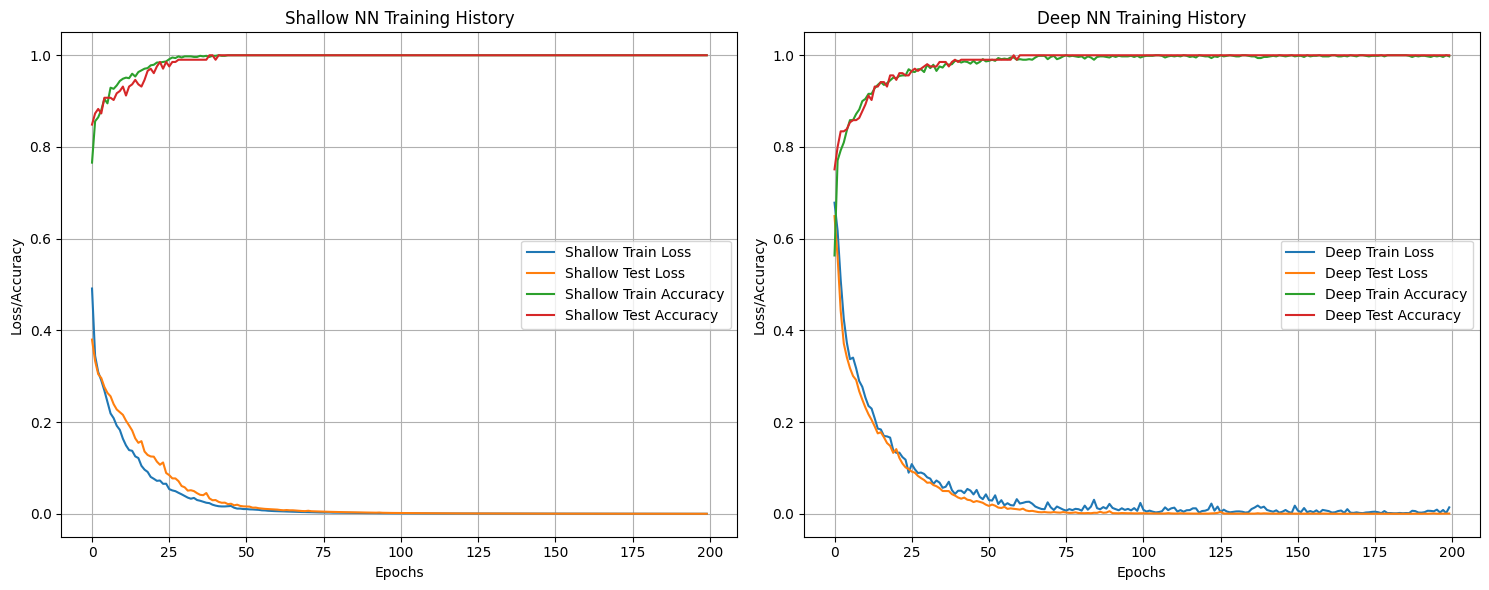

In [91]:
plt.figure(figsize=(15, 6))

# Shallow NN Training History
plt.subplot(1, 2, 1)
plt.plot(shallow_nn_history['train_losses'], label='Shallow Train Loss')
plt.plot(shallow_nn_history['val_losses'], label='Shallow Test Loss')
plt.plot(shallow_nn_history['train_accuracies'], label='Shallow Train Accuracy')
plt.plot(shallow_nn_history['val_accuracies'], label='Shallow Test Accuracy')
plt.title('Shallow NN Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.grid(True)

# Deep NN Training History
plt.subplot(1, 2, 2)
plt.plot(deep_nn_history['train_losses'], label='Deep Train Loss')
plt.plot(deep_nn_history['val_losses'], label='Deep Test Loss')
plt.plot(deep_nn_history['train_accuracies'], label='Deep Train Accuracy')
plt.plot(deep_nn_history['val_accuracies'], label='Deep Test Accuracy')
plt.title('Deep NN Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Both models show a rapid decrease in loss and a strong increase in accuracy during the first few epochs, indicating effective learning. The shallow network converges faster and reaches nearly 100% accuracy with very low loss in fewer epochs. In contrast, the deep network takes longer to stabilize but also achieves almost perfect accuracy, showing that both architectures perform well for heart disease classification.

### 2. Confusion Matrix

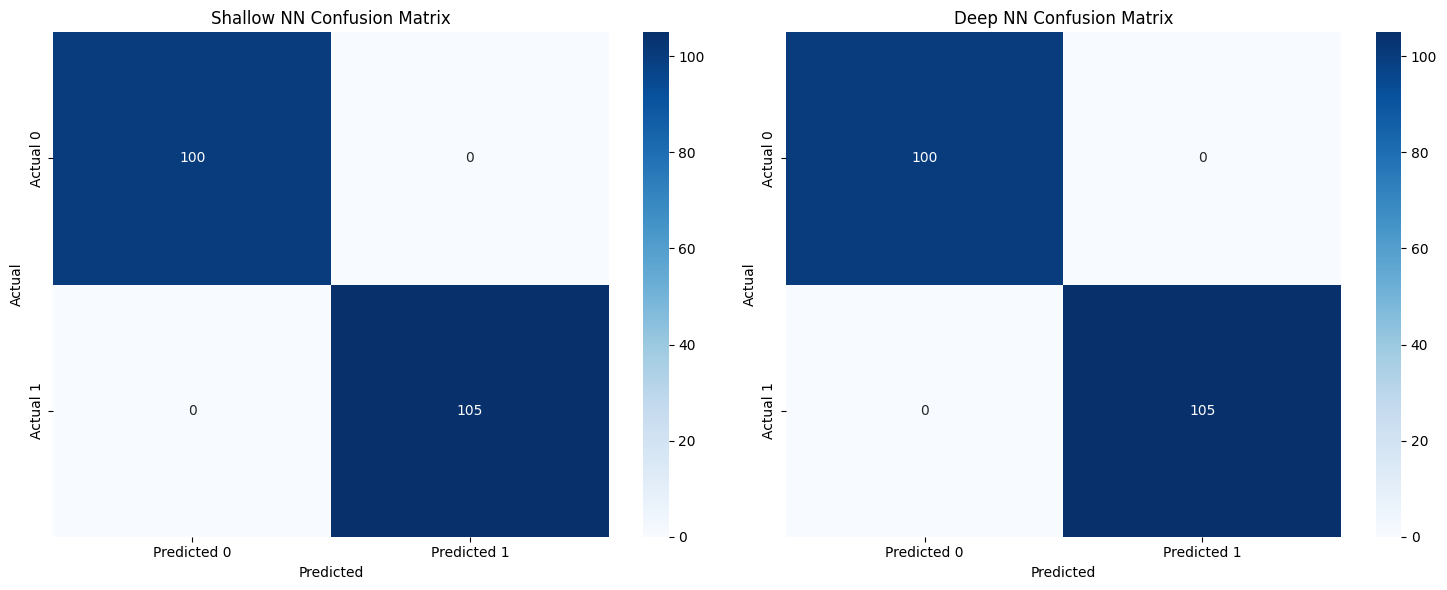

In [92]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(15, 6))

# Shallow NN Confusion Matrix
plt.subplot(1, 2, 1)
cm_shallow = confusion_matrix(y_true_shallow, y_pred_shallow)
sns.heatmap(cm_shallow, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Shallow NN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Deep NN Confusion Matrix
plt.subplot(1, 2, 2)
cm_deep = confusion_matrix(y_true_deep, y_pred_deep)
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Deep NN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

The confusion matrix shows that both the Shallow Neural Network and Deep Neural Network classified the Heart Disease dataset with perfect accuracy. Each model correctly predicted all 100 negative cases and 105 positive cases, with zero false positives and zero false negatives. This indicates excellent classification performance and strong model reliability. Since both models achieved identical results, they are equally effective for this dataset.

### 3. ROC Curve

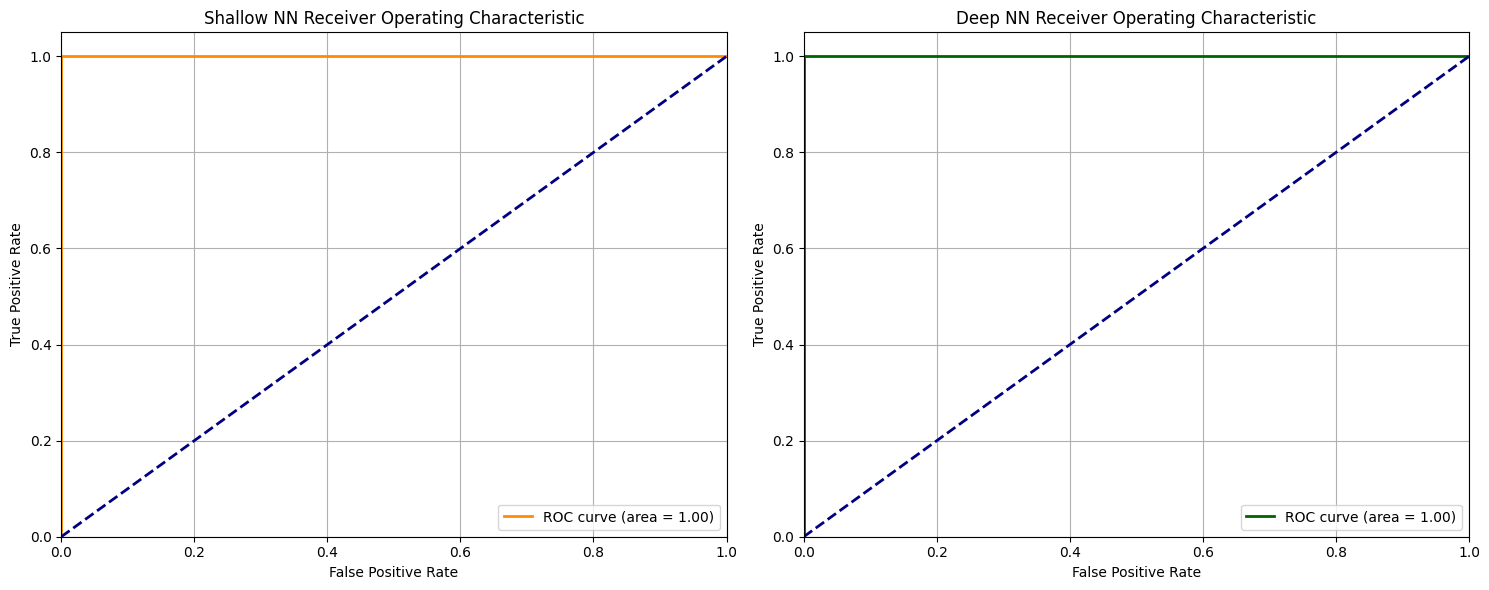

Shallow NN AUC Score: 1.0000
Deep NN AUC Score: 1.0000


In [93]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(15, 6))

# Shallow NN ROC Curve
plt.subplot(1, 2, 1)
fpr_shallow, tpr_shallow, _ = roc_curve(y_true_shallow, y_pred_shallow)
roc_auc_shallow = auc(fpr_shallow, tpr_shallow)
plt.plot(fpr_shallow, tpr_shallow, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_shallow:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Shallow NN Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True)

# Deep NN ROC Curve
plt.subplot(1, 2, 2)
fpr_deep, tpr_deep, _ = roc_curve(y_true_deep, y_prob_deep) # Use probabilities for ROC curve
roc_auc_deep = auc(fpr_deep, tpr_deep)
plt.plot(fpr_deep, tpr_deep, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_deep:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Deep NN Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Shallow NN AUC Score: {roc_auc_shallow:.4f}")
print(f"Deep NN AUC Score: {roc_auc_deep:.4f}")

The ROC curve shows that both the Shallow Neural Network and Deep Neural Network achieved an AUC score of 1.00, which indicates perfect classification performance on the Heart Disease dataset. Both curves stay at the top-left corner, meaning they have the highest possible true positive rate with zero false positive rate. This confirms that both models can distinguish between heart disease and non-heart disease cases very effectively. Overall, the ROC analysis proves both models are highly accurate and reliable.

### 4. Evaluation Metrics (Bar Chart)

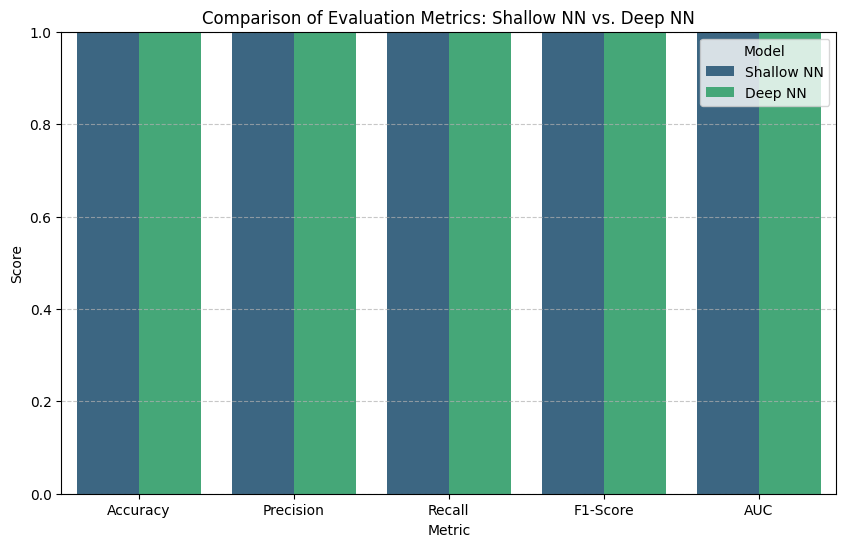

In [94]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Shallow NN': [accuracy_shallow, precision_shallow, recall_shallow, f1_shallow, auc_shallow],
    'Deep NN': [accuracy_deep, precision_deep, recall_deep, f1_deep, auc_deep]
})

metrics_df_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Evaluation Metrics: Shallow NN vs. Deep NN')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This bar chart compares the performance of the Shallow Neural Network and Deep Neural Network using key evaluation metrics on the Heart Disease dataset. Both models achieved a perfect score of 1.00 in Accuracy, Precision, Recall, F1-Score, and AUC, showing outstanding classification performance. The identical results indicate that both architectures are equally effective for this dataset. However, the shallow network may be more efficient due to its simpler structure and faster training time.

### 5. Network Structure

In [95]:
print("Shallow Neural Network Architecture")
print(best_shallow_nn)
print("\n")

print("Deep Neural Network Architecture")
print(best_deep_nn)


Shallow Neural Network Architecture
ShallowNN(
  (fc1): Linear(in_features=22, out_features=32, bias=True)
  (activation): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Deep Neural Network Architecture
DeepNN(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
  (sigmoid): Sigmoid()
)


Both the Shallow NN and Deep NN achieved perfect performance on the Heart Disease dataset, with all evaluation metrics scoring 1.00. The shallow model learned faster and required less complexity, while the deep model used multiple layers to capture more complex patterns. Since both produced identical results, the Shallow Neural Network is the better choice due to its simplicity and efficiency.